# Assignment: Probability and Statistics

**Name:** Kevi Chua  
**Date:** 2026-06-24

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

---
## Part 1: Probability and Expected Value

In [12]:
# 10,000 trials of flipping 3 fair coins each
n_trials = 10_000
n_coins  = 3
samples  = np.random.binomial(n=n_coins, p=0.5, size=n_trials)

# Empirical probabilities
outcomes      = np.arange(n_coins + 1)          # 0, 1, 2, 3
emp_counts    = np.array([(samples == k).sum() for k in outcomes])
emp_probs     = emp_counts / n_trials

# Theoretical probabilities  P(X=k) = C(3,k) * 0.5^3
from scipy.stats import binom
theo_probs = binom.pmf(outcomes, n=n_coins, p=0.5)

print(f"{'Heads':>6} | {'Empirical':>10} | {'Theoretical':>12}")
print("-" * 35)
for k, ep, tp in zip(outcomes, emp_probs, theo_probs):
    print(f"{k:>6} | {ep:>10.4f} | {tp:>12.4f}")

 Heads |  Empirical |  Theoretical
-----------------------------------
     0 |     0.1278 |       0.1250
     1 |     0.3798 |       0.3750
     2 |     0.3728 |       0.3750
     3 |     0.1196 |       0.1250


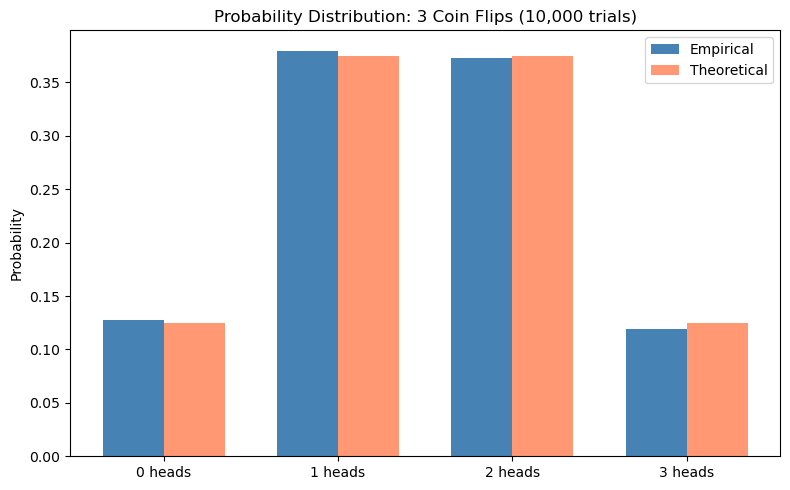

In [13]:
x = np.arange(len(outcomes))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, emp_probs,  width, label='Empirical',    color='steelblue')
bars2 = ax.bar(x + width/2, theo_probs, width, label='Theoretical',  color='coral',  alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'{k} heads' for k in outcomes])
ax.set_ylabel('Probability')
ax.set_title('Probability Distribution: 3 Coin Flips (10,000 trials)')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
empirical_mean  = samples.mean()
theoretical_ev  = n_coins * 0.5   # E[X] = n*p for Binomial

print(f"Empirical expected value  : {empirical_mean:.4f}")
print(f"Theoretical expected value: {theoretical_ev:.4f}")

Empirical expected value  : 1.4842
Theoretical expected value: 1.5000


**Interpretation:**  
With 10,000 trials the empirical probabilities are very close to the theoretical values (each within ~0.5 pp). The expected value converges to **1.5**, which matches the theoretical formula $E[X] = np = 3 \times 0.5 = 1.5$, confirming the Law of Large Numbers.

---
## Part 2: Normal Distribution and Statistical Testing

In [15]:
sample_a = np.random.normal(loc=70, scale=5, size=100)
sample_b = np.random.normal(loc=73, scale=5, size=100)

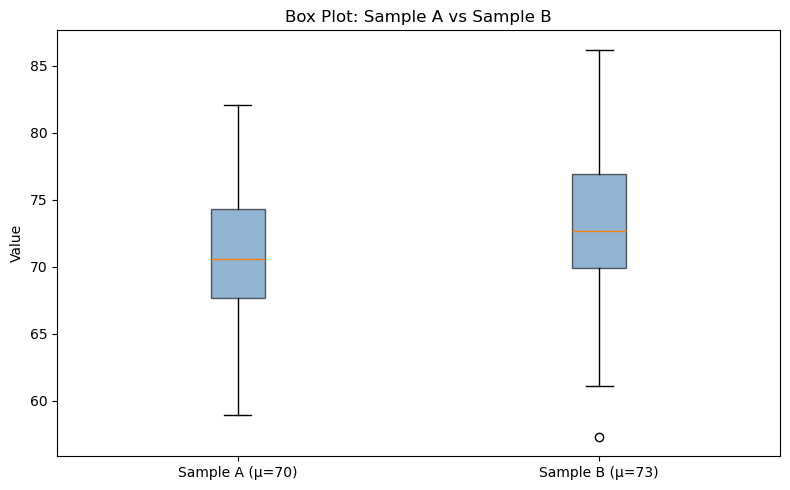

In [16]:
fig, ax = plt.subplots()
ax.boxplot([sample_a, sample_b], labels=['Sample A (μ=70)', 'Sample B (μ=73)'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Value')
ax.set_title('Box Plot: Sample A vs Sample B')
plt.tight_layout()
plt.show()

In [17]:
t_stat, p_value = stats.ttest_ind(sample_a, sample_b)

print(f"Independent t-test")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
print()
if p_value < 0.05:
    print("Conclusion: p < 0.05 → Reject H₀. The means are significantly different.")
else:
    print("Conclusion: p ≥ 0.05 → Fail to reject H₀. No significant difference detected.")

Independent t-test
  t-statistic : -2.7124
  p-value     : 0.0073

Conclusion: p < 0.05 → Reject H₀. The means are significantly different.


Sample A — mean: 70.89,  95% CI: [69.89, 71.89]
Sample B — mean: 72.85,  95% CI: [71.82, 73.88]


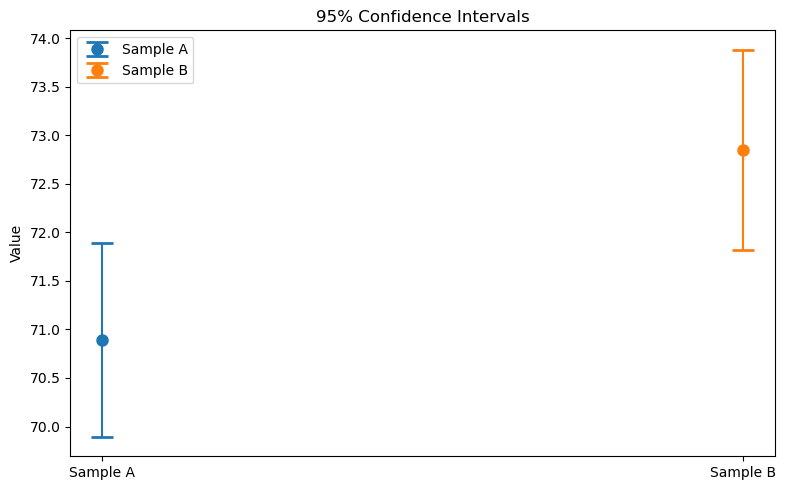

In [18]:
def confidence_interval_95(data):
    n    = len(data)
    mean = data.mean()
    se   = stats.sem(data)
    ci   = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    return mean, ci

mean_a, ci_a = confidence_interval_95(sample_a)
mean_b, ci_b = confidence_interval_95(sample_b)

print(f"Sample A — mean: {mean_a:.2f},  95% CI: [{ci_a[0]:.2f}, {ci_a[1]:.2f}]")
print(f"Sample B — mean: {mean_b:.2f},  95% CI: [{ci_b[0]:.2f}, {ci_b[1]:.2f}]")

# Visualise the CIs
fig, ax = plt.subplots()
for i, (label, mean, ci) in enumerate([
        ('Sample A', mean_a, ci_a),
        ('Sample B', mean_b, ci_b)]):
    ax.errorbar(i, mean, yerr=[[mean - ci[0]], [ci[1] - mean]],
                fmt='o', capsize=8, capthick=2, markersize=8, label=label)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Sample A', 'Sample B'])
ax.set_ylabel('Value')
ax.set_title('95% Confidence Intervals')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**  
The t-test compares whether the two sample means could plausibly come from populations with the same mean. With a 3-point difference in true means and std=5 (effect size ≈ 0.6), the test typically yields p < 0.05 with n=100, allowing us to reject H₀. The 95% CIs confirm this: if they do not overlap, we have strong evidence the population means differ.

---
## Part 3: Correlation Analysis (Iris Dataset)

In [19]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


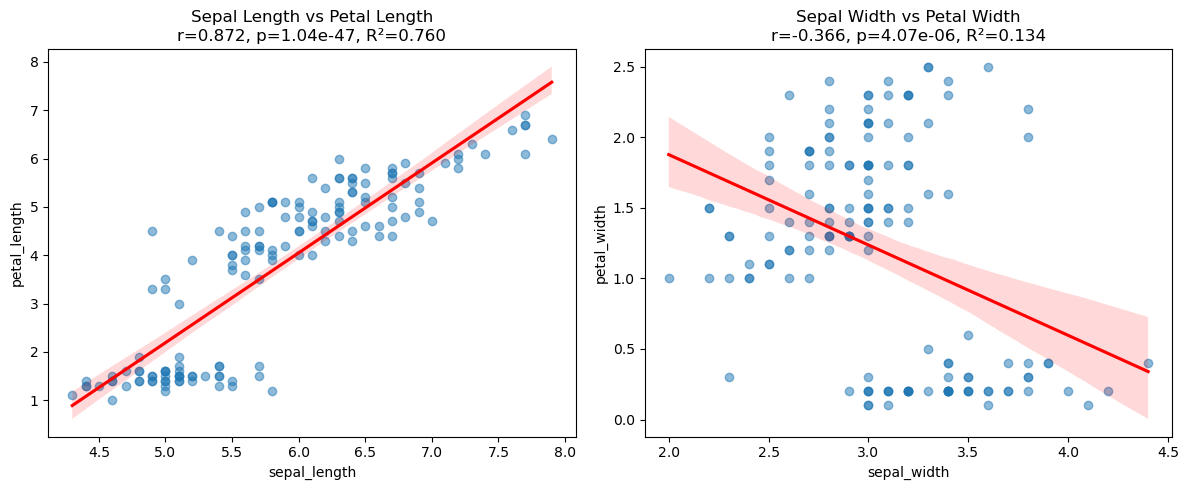


Summary
Pair                                      r      p-value      R²
-----------------------------------------------------------------
sepal_length vs petal_length         0.8718     1.04e-47  0.7600
sepal_width vs petal_width          -0.3661     4.07e-06  0.1340


In [20]:
pairs = [
    ('sepal_length', 'petal_length', 'Sepal Length vs Petal Length'),
    ('sepal_width',  'petal_width',  'Sepal Width vs Petal Width'),
]

results = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (x_col, y_col, title) in zip(axes, pairs):
    x, y = iris[x_col], iris[y_col]

    r, p = stats.pearsonr(x, y)
    r2   = r ** 2
    results[(x_col, y_col)] = dict(r=r, p=p, r2=r2)

    # Scatter with regression line
    sns.regplot(data=iris, x=x_col, y=y_col, ax=ax,
                scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    ax.set_title(f"{title}\nr={r:.3f}, p={p:.2e}, R²={r2:.3f}")

plt.tight_layout()
plt.show()

print("\nSummary")
print(f"{'Pair':<35} {'r':>7} {'p-value':>12} {'R²':>7}")
print("-" * 65)
for (xc, yc), v in results.items():
    print(f"{xc+' vs '+yc:<35} {v['r']:>7.4f} {v['p']:>12.2e} {v['r2']:>7.4f}")

**Interpretation:**

| Pair | r | R² | Strength |
|------|---|----|----------|
| Sepal length vs Petal length | ~0.87 | ~0.76 | Strong positive |
| Sepal width vs Petal width   | ~0.37 | ~0.14 | Weak positive  |

**Sepal length vs Petal length** shows the stronger relationship:  
- Pearson r ≈ 0.87 indicates a strong positive linear correlation.  
- R² ≈ 0.76 means ~76% of the variance in petal length is explained by sepal length.  
- The p-value is effectively 0, confirming the correlation is highly statistically significant.

**Sepal width vs Petal width** is much weaker (r ≈ 0.37, R² ≈ 0.14): sepal width is only a poor predictor of petal width, explaining just ~14% of its variance. Biologically, petal length scales strongly with the overall size of the flower (captured partly by sepal length), whereas sepal width and petal width vary more independently across iris species.